**Objective**

The goal of this notebook is to build and evaluate regression-based models
to forecast monthly sales using engineered time-series features such as
lag variables, rolling statistics, and calendar attributes.


**Load Data**

In [20]:
import pandas as pd

df=pd.read_csv("../data/monthly_sales_features.csv",parse_dates=["Order Date"])
df.set_index("Order Date",inplace=True)
df.head()

,Sales,month,year,lag_1,lag_2,lag_3,rolling_mean_3,rolling_mean_6
Order Date,,,,,,,,
2014-07-31,33946.3930,7,2014,34595.1276,28295.3450,14236.895,28846.253200,26831.092600
2014-08-31,27909.4685,8,2014,33946.3930,23648.2870,4519.892,30729.935867,30116.008933
2014-09-30,81777.3508,9,2014,27909.4685,34595.1276,55691.009,32150.329700,34014.271683
2014-10-31,31453.3930,10,2014,81777.3508,33946.3930,28295.345,47877.737433,38361.995317
2014-11-30,78628.7167,11,2014,31453.3930,27909.4685,23648.287,47046.737433,38888.336650


In [21]:
type(df.index)


pandas.core.indexes.datetimes.DatetimeIndex

**Defining Features(X) and Target(y)**

In [22]:
X=df.drop("Sales",axis=1)
y=df["Sales"]

- Target variable: Monthly Sales
- Features: Lag values, rolling means, and calendar features


**Time-Aware Train–Test Split**

In [23]:
split_date="2017-01-01"

X_train=X[X.index < split_date]
X_test=X[X.index >= split_date]

y_train=y[y.index < split_date]
y_test=y[y.index >= split_date]

The data is split chronologically to prevent data leakage from future observations.


**Baseline Model: Linear Regression**

In [24]:
from sklearn.linear_model import LinearRegression

lr=LinearRegression()
lr.fit(X_train,y_train)

y_pred_lr=lr.predict(X_test)

**Model Evaluation**

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np  

mae_lr=mean_absolute_error(y_test,y_pred_lr)
rmse_lr=np.sqrt(mean_squared_error(y_test,y_pred_lr))

print(f"Linear Regression MAE: {mae_lr}")
print(f"Linear Regression RMSE: {rmse_lr}")

Linear Regression MAE: 14984.762883573616
Linear Regression RMSE: 17849.945838929067


- Lower RMSE indicates better forecasting accuracy.
- This model serves as a baseline for future comparisons.


**Actual Vs Predicted**

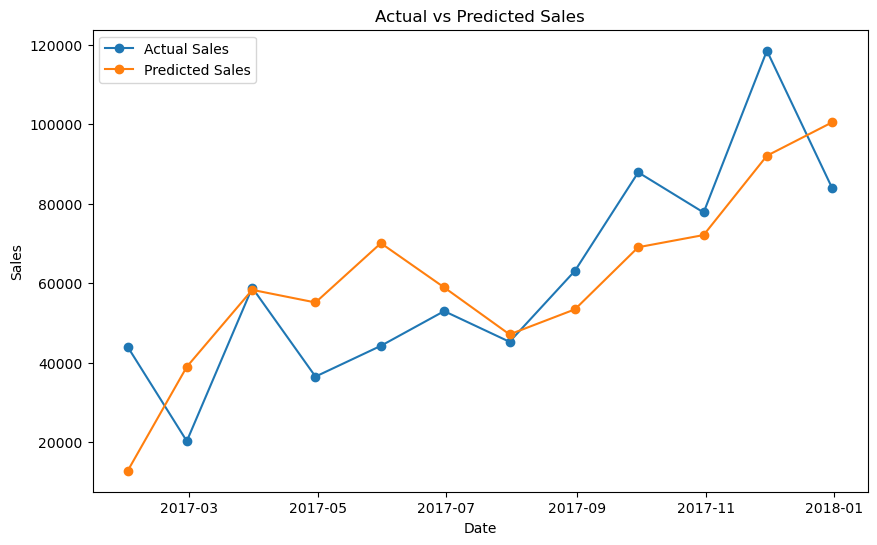

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(y_test.index, y_test, label='Actual Sales', marker='o')
plt.plot(y_test.index, y_pred_lr, label='Predicted Sales', marker='o')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Actual vs Predicted Sales')
plt.legend()
plt.show()

**Feature Importance**

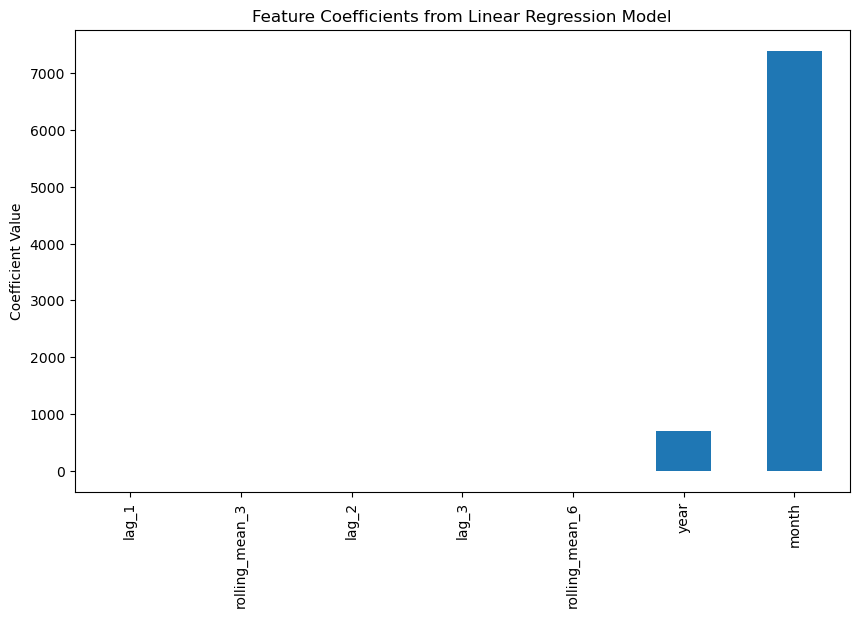

In [31]:
coefficients = pd.Series(lr.coef_, index=X_train.columns)
coefficients.sort_values().plot(kind='bar', figsize=(10,6))
plt.title('Feature Coefficients from Linear Regression Model')
plt.ylabel('Coefficient Value')
plt.show()

